In [195]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import (
    load_predictions,
    load_all_samples,
    clean_model_name,
)
from xarch_tokenizers.logging.plot_utils import (
    setup_styles,
    get_new_6_fig,
    MODEL_TO_COLOR,
    get_new_fig,
)


setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [196]:


def get_canonical_and_perturbed_df(
    samples,
    only_keep_canonical_true: bool = False,
    keep_remains_or_becomes_correct: bool = False,
    only_keep_perturbed_true: bool = False,
):
    """returns filtered out samples too"""
    if (
        (only_keep_canonical_true and keep_remains_or_becomes_correct)
        or (only_keep_canonical_true and only_keep_perturbed_true)
        or (keep_remains_or_becomes_correct and only_keep_perturbed_true)
    ):
        raise ValueError(
            f"Please pass these exclusively, only_keep_canonical_true: true for canonical, model_name true, keep_remains_or_becomes_correct: True to include the ones where the perturbed version becomes correct"
        )
    print(f"Processing {len(samples)} examples")
    canonical_samples = samples[samples["is_canonical"]]
    perturbed_samples = samples[~samples["is_canonical"]]
    canonical_values = canonical_samples[["set_id", "model_name", METRIC]].rename(
        columns={METRIC: f"canonical_{METRIC}"}
    )

    perturbed_samples = perturbed_samples.merge(
        canonical_values, on=["set_id", "model_name"], how="left"
    )
    perturbed_samples[f"canonical-perturbed_{METRIC}"] = (
        perturbed_samples[f"canonical_{METRIC}"] - perturbed_samples[METRIC]
    )

    if only_keep_canonical_true:
        print(
            f"Cleaning samples, will be dropping entries (set_id-model pairs) where the canonical is predicted wrong."
        )
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]
        print(
            f"Keeping {len(correct_canonical_pairs)} correct pairs, dropping {len(canonical_samples) - len(correct_canonical_pairs)} entries."
        )

        canonical_samples = canonical_samples[canonical_samples[METRIC] == 1]

        # Step 3: Filter perturbed_samples to keep only rows with correct canonical pairs
        # Method 1: Using merge (RECOMMENDED)
        perturbed_samples = perturbed_samples.merge(
            correct_canonical_pairs,
            on=["set_id", "model_name"],
            how="inner",  # Only keep rows that exist in both
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)

    if keep_remains_or_becomes_correct:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        correct_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ]

        # Combine: pairs that either remain correct OR become correct
        remains_or_becomes_correct = pd.concat(
            [correct_canonical_pairs, correct_perturbed_pairs]
        ).drop_duplicates()

        # Filter both datasets to only include these pairs
        canonical_samples = canonical_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        perturbed_samples = perturbed_samples.merge(
            remains_or_becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        samples = pd.concat((canonical_samples, perturbed_samples), ignore_index=True)
        print(f"After filtering:{len(samples)}")
    if only_keep_perturbed_true:
        # Get pairs where perturbed samples are correct (becomes or remains correct)
        correct_perturbed_pairs = perturbed_samples[perturbed_samples[METRIC] == 1][
            ["set_id", "model_name"]
        ].drop_duplicates()

        # Get pairs where canonical samples are correct (remains correct)
        wrong_canonical_pairs = canonical_samples[canonical_samples[METRIC] == 0][
            ["set_id", "model_name"]
        ]
        # Find cases where canonical wrong AND perturbed correct (recovery cases)
        becomes_correct = pd.merge(
            wrong_canonical_pairs,
            correct_perturbed_pairs,
            how="inner",
            on=["set_id", "model_name"], 
        )
        print(becomes_correct)

        # Filter both datasets to only include recovery cases
        canonical_samples = canonical_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )
        print(canonical_samples[METRIC].sum())

        perturbed_samples = perturbed_samples.merge(
            becomes_correct, on=["set_id", "model_name"], how="inner"
        )

        samples = pd.concat([canonical_samples, perturbed_samples], ignore_index=True)
        print(f"After filtering: {len(samples)}")

    return samples, canonical_samples, perturbed_samples

## Farsi Subset

In [ ]:
METRIC = "acc_norm"
OUTPUT_DIR_ = Path("./output/prelim-results-v3")

suffix = "(Still correct)"
only_keep_canonical_true = True
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

# suffix = "(Remains or Becomes Correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = True
# only_keep_perturbed_true = False

# suffix = "(Flipped to correct)"
# only_keep_canonical_true = False
# keep_remains_or_becomes_correct = False
# only_keep_perturbed_true = True

suffix = "(All)" 
only_keep_canonical_true = False
keep_remains_or_becomes_correct = False
only_keep_perturbed_true = False

base_dir = Path("../results/paper").resolve().absolute()
base_dir = Path("../results/paper-v2").resolve().absolute()
code_pattern = "*farsi_tokenizer*"
title_pattern = "Farsi - "
OUTPUT_DIR = OUTPUT_DIR_/"farsi"

code_pattern = "*tokenizer_robustness_completion_turkish*"
title_pattern = "Turkish - "
OUTPUT_DIR = OUTPUT_DIR_/"turkish"

# code_pattern = "*tokenizer_robustness_completion_stem*"
# title_pattern = "STEM - "
# OUTPUT_DIR = OUTPUT_DIR_/"stem"


code_pattern = "*tokenizer_robustness_completion_math*"
title_pattern = "MATH - "
OUTPUT_DIR = OUTPUT_DIR_/"math"

code_pattern = "*tokenizer_robustness_completion_english*"
title_pattern = "English - "
OUTPUT_DIR = OUTPUT_DIR_/"english"

# code_pattern = "*tokenizer_robustness_completion_chinese*"
# title_pattern = "Chinese - "
# OUTPUT_DIR = OUTPUT_DIR_/"chinese"

SUFFIX = suffix.lower().replace("(","").replace(")","")
OUTPUT_DIR = OUTPUT_DIR/SUFFIX
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
base_dir = Path("../results/paper-v3").resolve().absolute()
base_dir.exists()
pred_files = list([p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")])
len(pred_files), pred_files[:5]


(126,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_cannonical_2025-09-15T15-18-28.730137.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_latex_2025-09-15T15-18-28.730137.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_turkish_2025-09-15T15-18-28.730137.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_farsi_2025-09-15T15-18-28.730137.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion

In [198]:
all_samples = load_all_samples(
    base_dir,
    patterns=[code_pattern],
    flatten_doc=True,
    match_date=False,
    simplify_df=True,
)
all_samples["is_canonical"] = (
    all_samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
)
all_samples = all_samples[all_samples["subcategories"] != "Turkish, Numerical formats"]
all_samples = all_samples[all_samples["task"] != "tokenizer_robustness_completion_english_space_additions"]

samples, canonical_df, perturbed_df = get_canonical_and_perturbed_df(
    all_samples,
    only_keep_canonical_true=only_keep_canonical_true,
    keep_remains_or_becomes_correct=keep_remains_or_becomes_correct,
    only_keep_perturbed_true=only_keep_perturbed_true,
)

samples.head()
samples["subcategories"].value_counts()
all_samples["set_id"].value_counts()

126 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_cannonical_2025-09-15T15-18-28.730137.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_latex_2025-09-15T15-18-28.730137.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_turkish_2025-09-15T15-18-28.730137.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_farsi_2025-09-15T15-18-28.730137.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper-v3/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_decor

set_id
200.0    126
211.0    126
219.0    126
218.0    126
217.0    126
216.0    126
215.0    126
214.0    126
213.0    126
212.0    126
210.0    126
201.0    126
209.0    126
208.0    126
207.0    126
206.0    126
205.0    126
204.0    126
203.0    126
202.0    126
220.0    126
Name: count, dtype: int64

In [199]:
pv = all_samples.pivot_table(index=["model_name", "is_canonical"], values=METRIC)
pv.to_csv(OUTPUT_DIR/f"model_canonical_{METRIC}.csv")
pv

acc_norm
model_name   is_canonical          
Aya          False         0.535714
             True          0.619048
Bloom        False         0.529762
             True          0.809524
ByT5         False         0.529762
             True          0.714286
Comma        False         0.589286
             True          0.857143
GPT-2        False         0.541667
             True          0.809524
GPT-4o       False         0.666667
             True          0.904762
Gemma-2      False         0.577381
             True          0.761905
LLaMA        False         0.613095
             True          0.809524
MBERT        False         0.541667
             True          0.619048
Phi-3        False         0.625000
             True          0.809524
Qwen-3       False         0.642857
             True          0.952381
Tekken       False         0.607143
             True          0.761905
TokenMonster False         0.559524
             True          0.666667
XGLM         False         0.559524
             True          0.761905

              acc_norm
model_name            
Aya           0.544974
Bloom         0.560847
ByT5          0.550265
Comma         0.619048
GPT-2         0.571429
GPT-4o        0.693122
Gemma-2       0.597884
LLaMA         0.634921
MBERT         0.550265
Phi-3         0.645503
Qwen-3        0.677249
Tekken        0.624339
TokenMonster  0.571429
XGLM          0.582011


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_57010/2494234973.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette=MODEL_TO_COLOR)


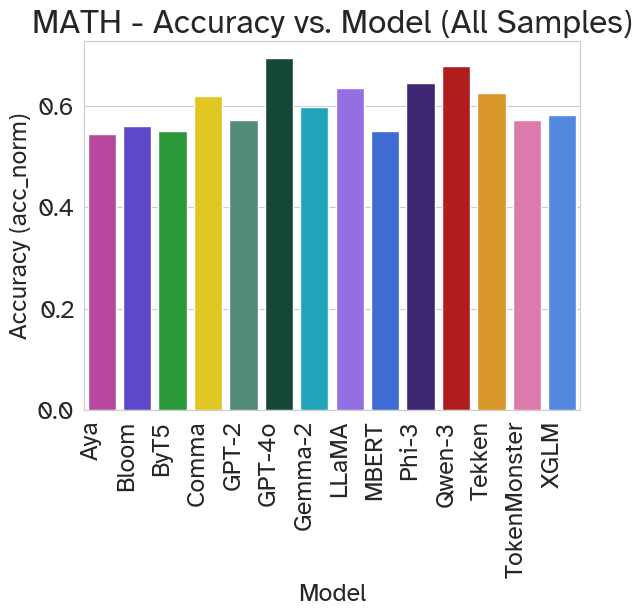

In [200]:
### Here using ALL SAMPLES

accuracies_by_model = all_samples.pivot_table(
    index="model_name", values=METRIC, aggfunc="mean"
)
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model (All Samples)")
plt.savefig(OUTPUT_DIR/f"all_samples_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

### Canonical vs. Pertuerbed

                           acc_norm
model_name   is_canonical          
Aya          False         0.535714
             True          0.619048
Bloom        False         0.529762
             True          0.809524
ByT5         False         0.529762
             True          0.714286
Comma        False         0.589286
             True          0.857143
GPT-2        False         0.541667
             True          0.809524
GPT-4o       False         0.666667
             True          0.904762
Gemma-2      False         0.577381
             True          0.761905
LLaMA        False         0.613095
             True          0.809524
MBERT        False         0.541667
             True          0.619048
Phi-3        False         0.625000
             True          0.809524
Qwen-3       False         0.642857
             True          0.952381
Tekken       False         0.607143
             True          0.761905
TokenMonster False         0.559524
             True          0

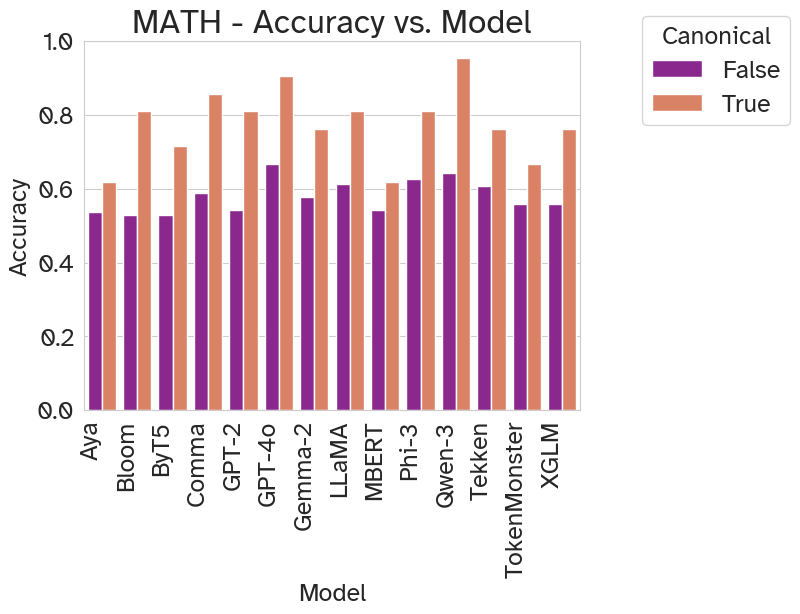

In [201]:
accuracies_by_model = all_samples.pivot_table(
    index=["model_name", "is_canonical"], values=METRIC, aggfunc="mean"
)
# sns.barplot(accuracies_by_model, x="is_canonical", y=METRIC, hue="model_name", palette=MODEL_TO_COLOR)
# xlabel = "Canonical"
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, hue="is_canonical", palette="plasma")
xlabel = "Model"
plt.xticks(rotation=90, ha="right")
plt.xlabel(xlabel)
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")
plt.legend(bbox_to_anchor=(1.1, 1.1), title="Canonical")
plt.savefig(OUTPUT_DIR/f"canonical_vs_perturbed_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

In [ ]:
accuracies_by_model = all_samples.copy()
accuracies_by_model = all_samples.pivot_table(
    index=["set_id", "model_name", "is_canonical"], values=METRIC, aggfunc="mean"
).reset_index()
fig, axs = plt.subplots(2, 1, figsize=(24, 6), sharex=True)
axs = axs.flat
sns.barplot(
    accuracies_by_model[accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[0],
    legend=False,
)
axs[0].set_title("Canonical")
axs[1].set_title("Perturbed")

sns.barplot(
    accuracies_by_model[~accuracies_by_model["is_canonical"]],
    x="set_id",
    y=METRIC,
    hue="model_name",
    palette=MODEL_TO_COLOR,
    ax=axs[1],
    legend=True,
)
axs[1].legend(bbox_to_anchor=(0.8, -0.8, 0, 0), ncol=7)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Set Id")
axs[0].set_ylabel(f"Accuracy ({METRIC})")
axs[1].set_ylabel(f"Accuracy ({METRIC})")
fig.suptitle(f"{title_pattern}Accuracy vs. Model by Sets")
plt.savefig(OUTPUT_DIR/f"by_samples_canonical_vs_perturbed.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

                                           acc_norm
model_name task_pretty_name                        
Aya        Canonical                       0.825000
           Code/language/script switching  0.717391
           Colloquial                      0.710526
           Derivations                     0.720930
           Dialects                        0.666667
...                                             ...
XGLM       Similar words                   0.640000
           Spelled out                     0.545455
           Typographical errors            0.717949
           Web search query                0.555556
           Word reordering                 0.704545

[210 rows x 1 columns]


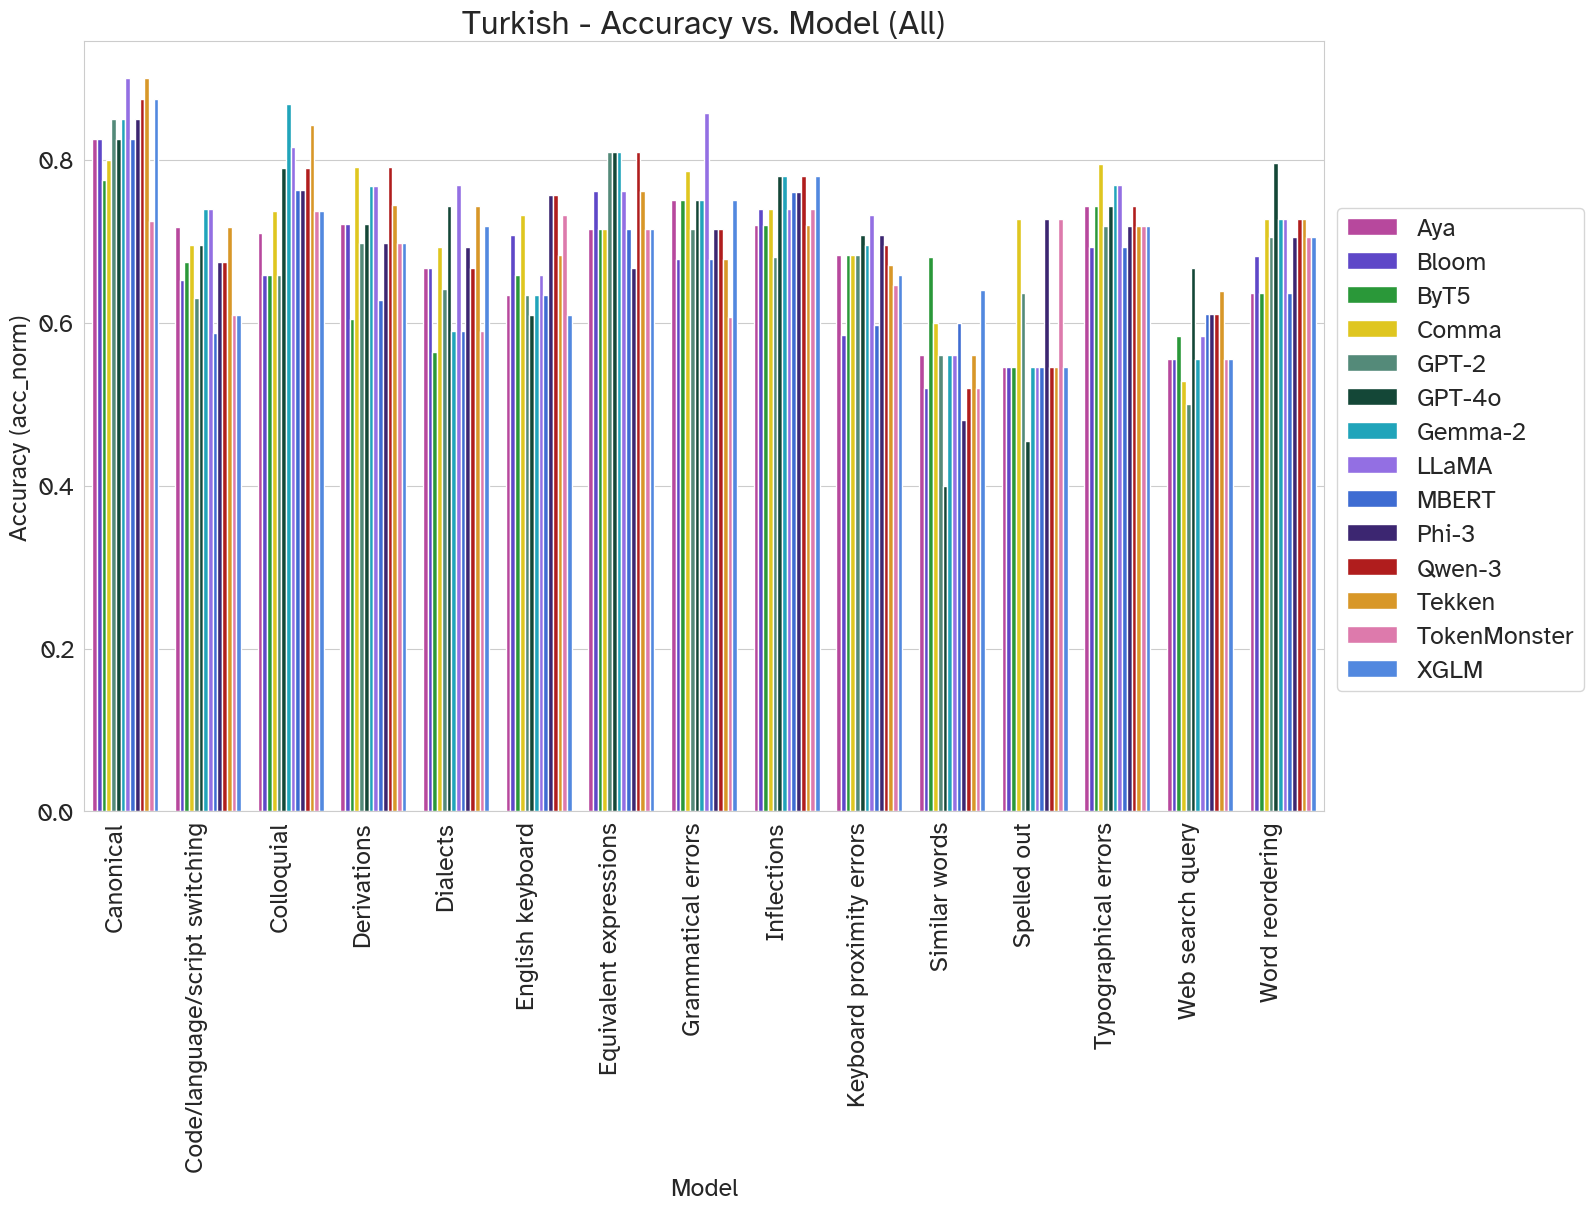

In [ ]:
from xarch_tokenizers.logging.plot_utils import MODEL_TO_COLOR

accuracies_by_model = samples.pivot_table(
    index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="mean"
)
fig, axs = plt.subplots(1, 1, figsize=(16, 10))
sns.barplot(
    accuracies_by_model,
    x="task_pretty_name",
    y=METRIC,
    hue="model_name",
    # palette="viridis",
    palette=MODEL_TO_COLOR,
)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel(f"Accuracy ({METRIC})")
plt.title(f"{title_pattern}Accuracy vs. Model {suffix}")
plt.legend(bbox_to_anchor=(1, 0.8))
plt.savefig(OUTPUT_DIR/f"combined_{METRIC}.pdf", pad_inches=0, bbox_inches="tight")

print(accuracies_by_model)

Plotting Canonical into position 1
1 False False
Plotting Similar words into position 2
2 False False
Plotting Colloquial into position 3
3 False False
Plotting Inflections into position 4
4 False False
Plotting Dialects into position 5
5 False False
Plotting Typographical errors into position 6
6 False False
Plotting Web search query into position 7
7 False False
Plotting English keyboard into position 8
8 False True


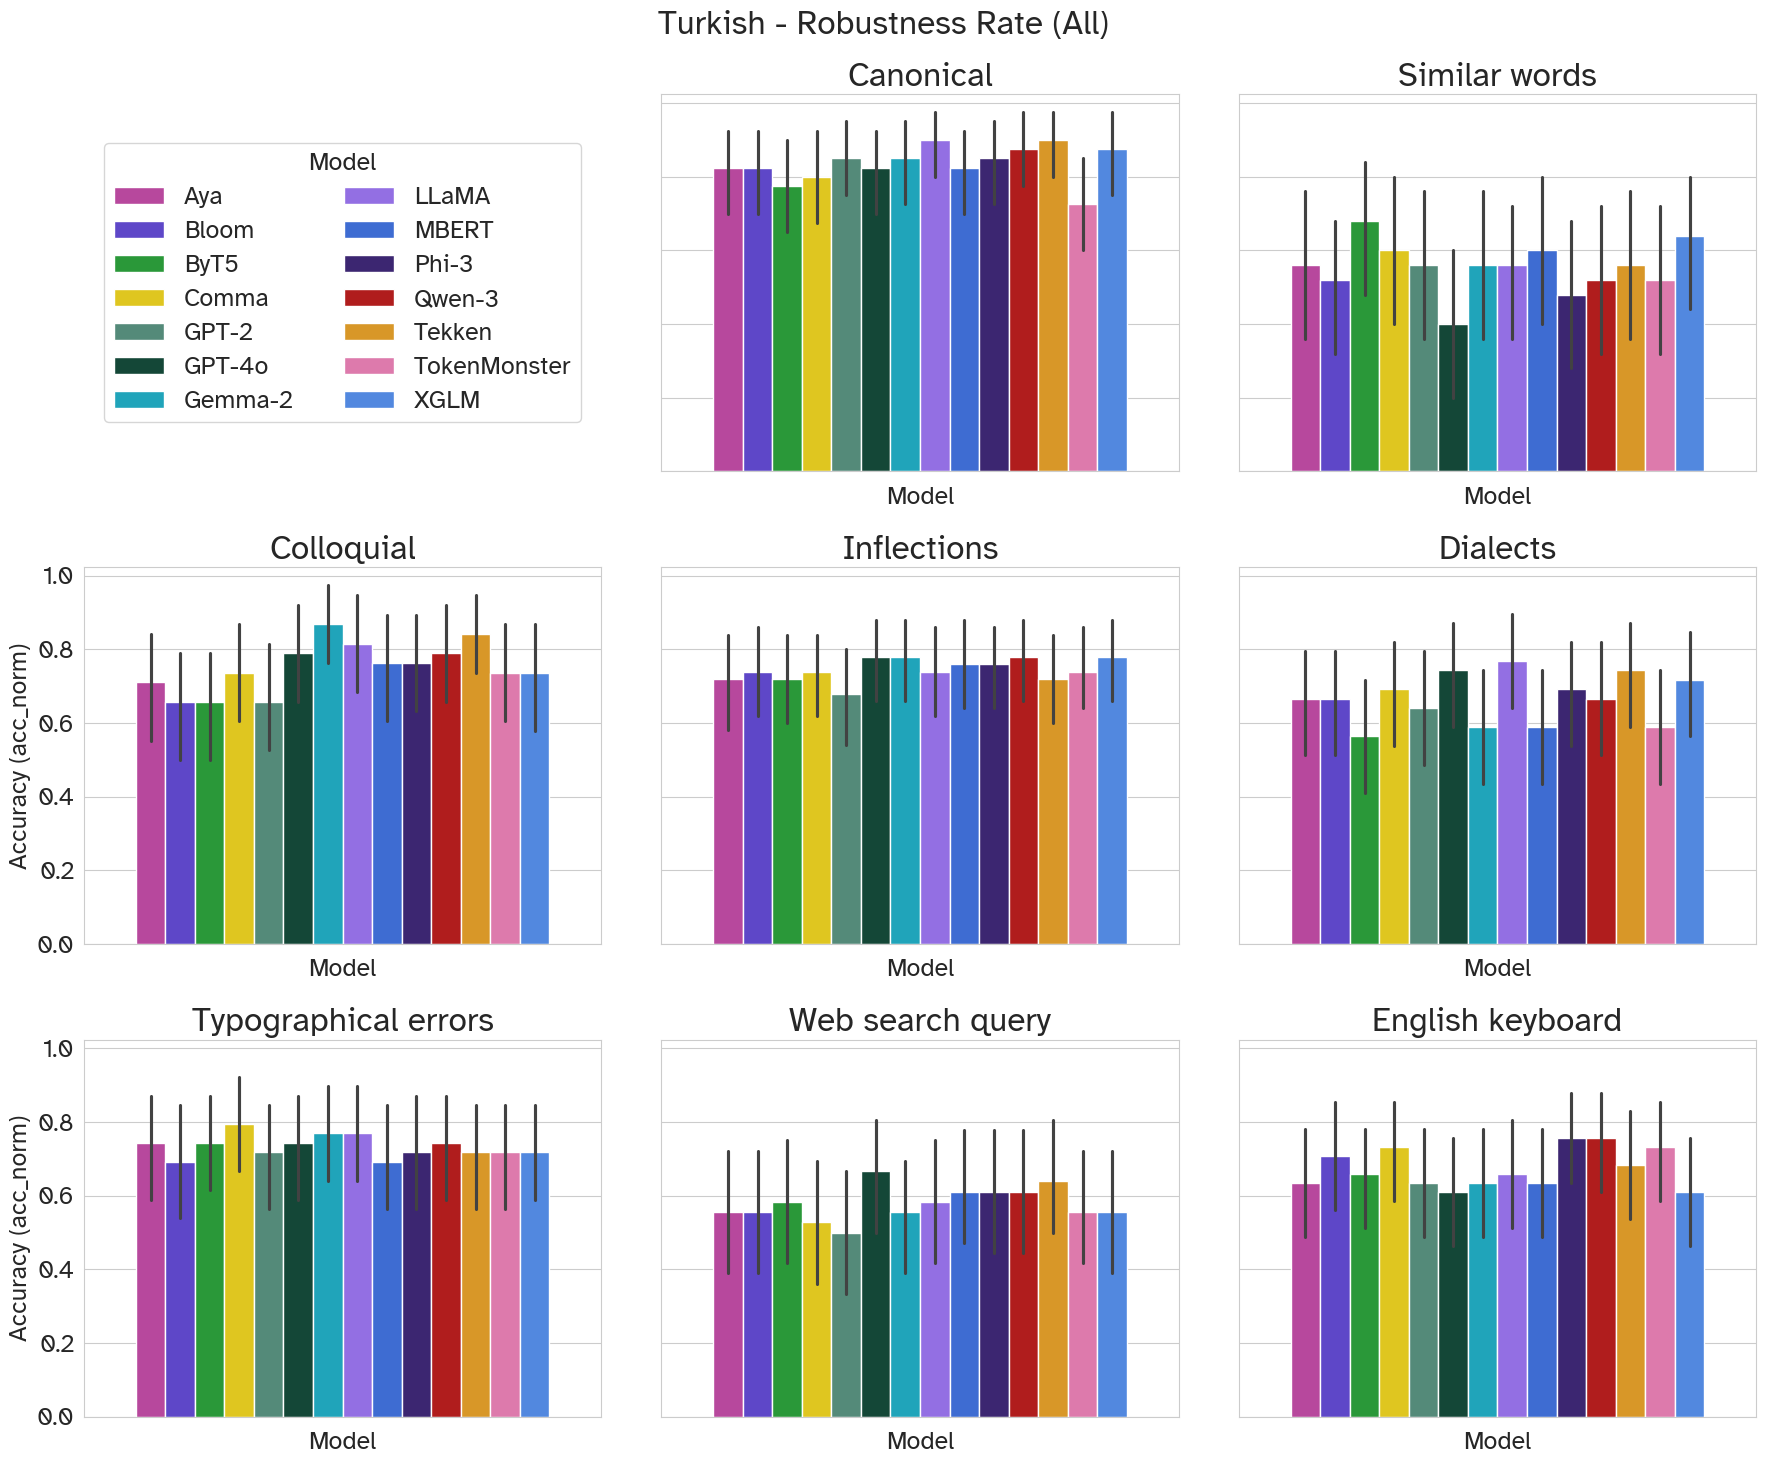

Plotting Keyboard proximity errors into position 0
9 False False
Plotting Derivations into position 1
10 False False
Plotting Word reordering into position 2
11 False False
Plotting Code/language/script switching into position 3
12 False False
Plotting Spelled out into position 4
13 False False
Plotting Equivalent expressions into position 5
14 False False
Plotting Grammatical errors into position 6
15 False False


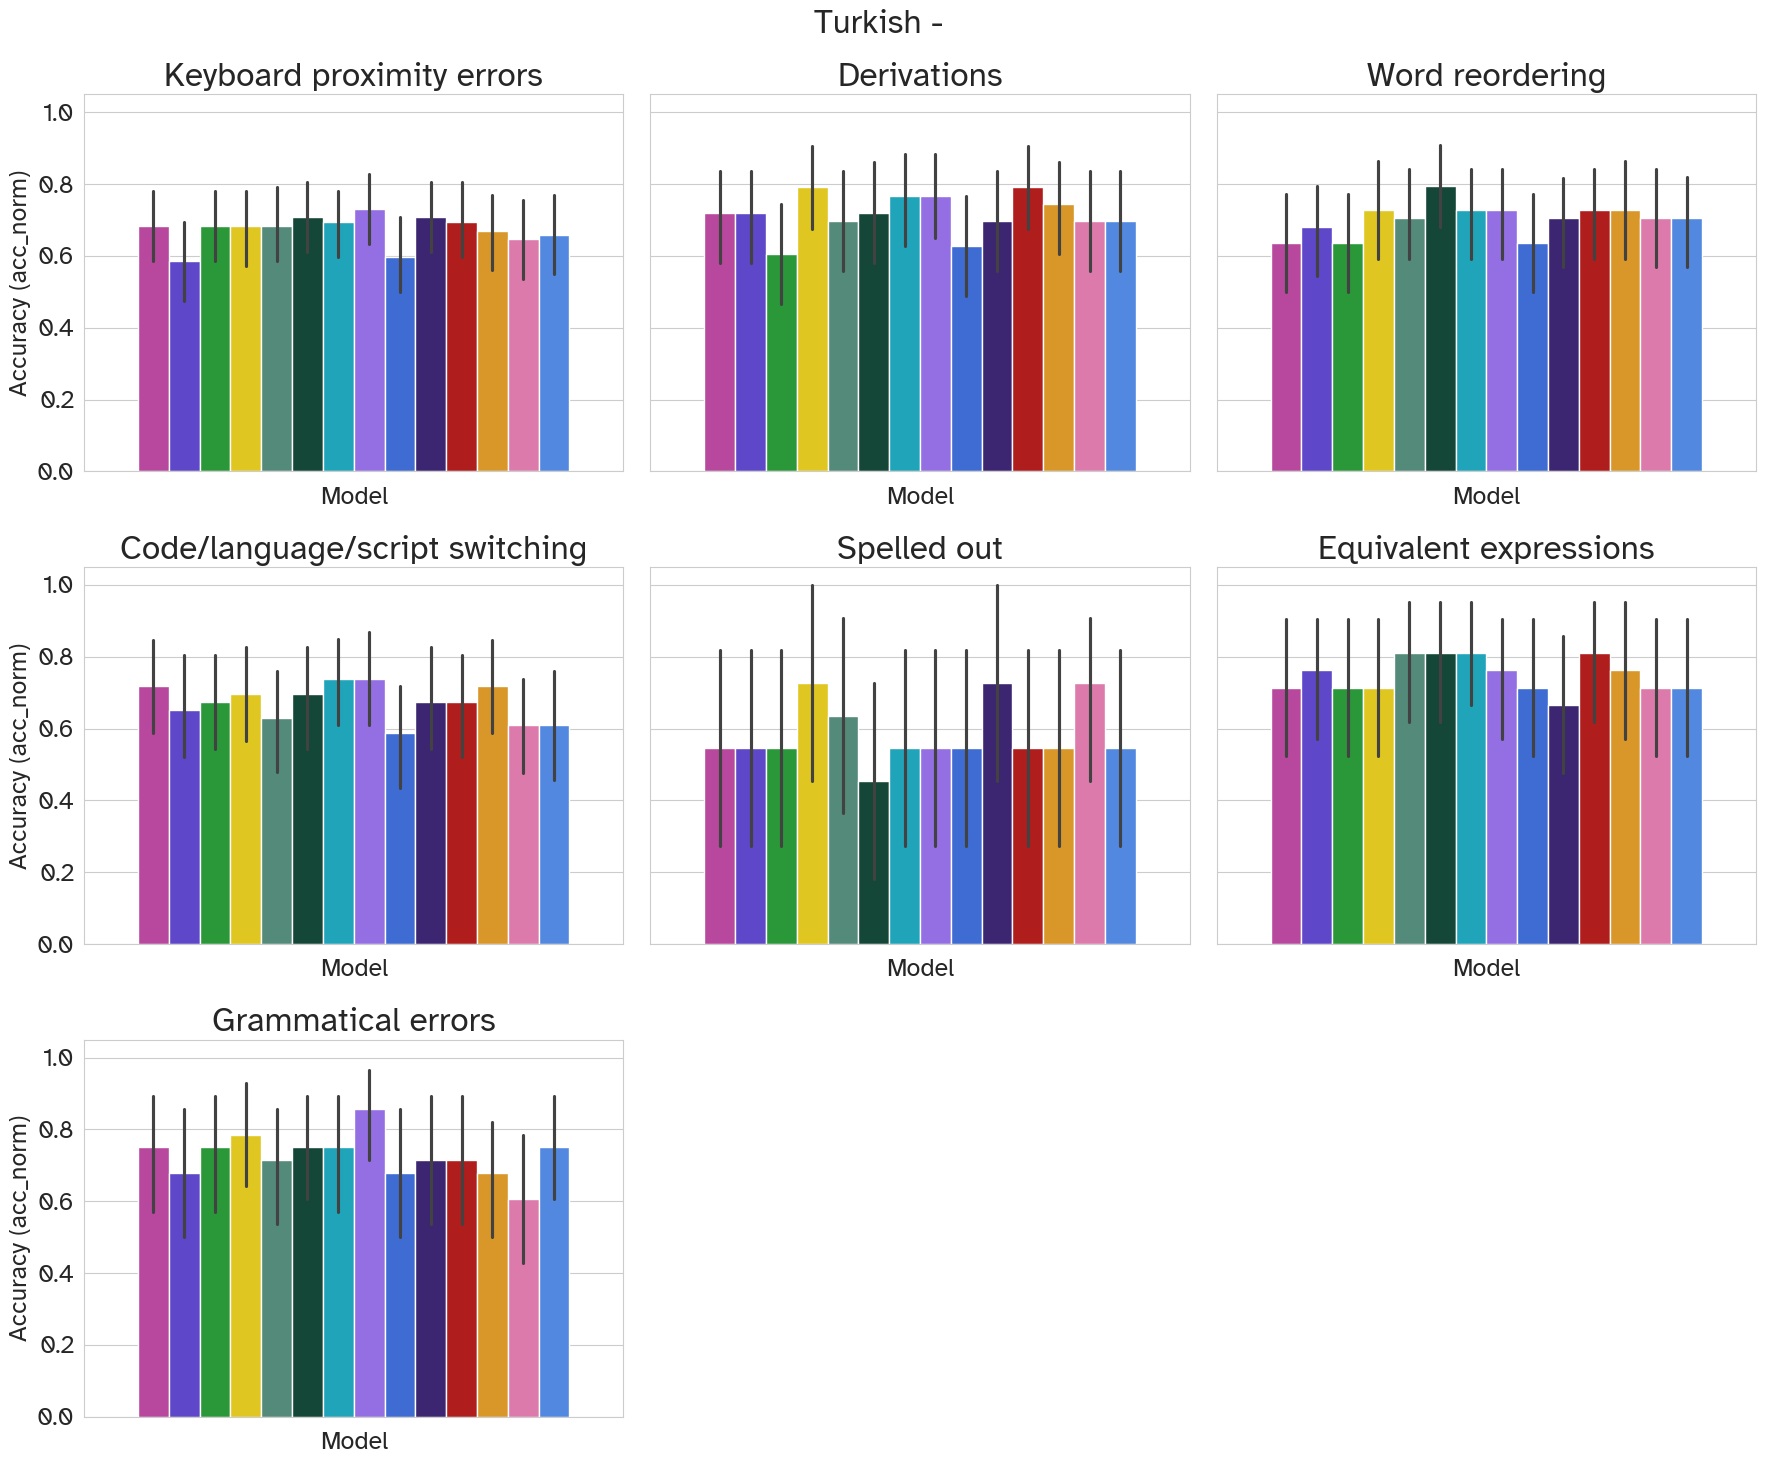

                                           acc_norm
model_name task_pretty_name                        
Aya        Canonical                       0.825000
           Code/language/script switching  0.717391
           Colloquial                      0.710526
           Derivations                     0.720930
           Dialects                        0.666667
...                                             ...
XGLM       Similar words                   0.640000
           Spelled out                     0.545455
           Typographical errors            0.717949
           Web search query                0.555556
           Word reordering                 0.704545

[210 rows x 1 columns]


In [ ]:
nrows, ncols = 3, 3
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
samples = samples.sort_values(["model_name", "set_id", "variation_id"])
tasks = samples["task_pretty_name"].unique()
# tasks = tasks[1:]
for i, task in enumerate(tasks, 1):
    print(f"Plotting {task} into position {i % len(axs)}")
    filter_ = samples["task_pretty_name"] == task
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue="model_name", y=METRIC, palette=MODEL_TO_COLOR, ax=ax, legend=i == 1
    )
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title = (
        task.replace("tokenizer_robustness_completion_", "")
        .replace(f"{code_pattern.replace('*', '')}_", "")
        .replace("farsi_", "")
        .replace("turkish_", "")
        .replace("italian_", "")
        .replace("chinese_", "")
        .replace("math_", "")
        .replace("stem_", "")
    )
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(tasks) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Model", loc="center", ncol=2)
        axs[1].legend().set_visible(False)
    print(i, is_last_task, is_end_of_6)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            print(f"Last task: {i}, {task}")
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)
            break

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
        fig_cnt += 1
# Hide any unused subplots if there are fewer than 6 tasks
for j in range((len(tasks) + 1) % (ncols * nrows), ncols * nrows):
    axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_task_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
plt.show()

print(accuracies_by_model)

### By Model

In [ ]:
OUTPUT_DIR.absolute()

PosixPath('/Users/gsaltintas/code/phd/tokenizers/notebooks/output/prelim-results-v3/turkish/all')

Plotting Aya into position 1
Plotting Bloom into position 2
Plotting ByT5 into position 3
Plotting Comma into position 4
Plotting GPT-2 into position 5
Plotting GPT-4o into position 6
Plotting Gemma-2 into position 7


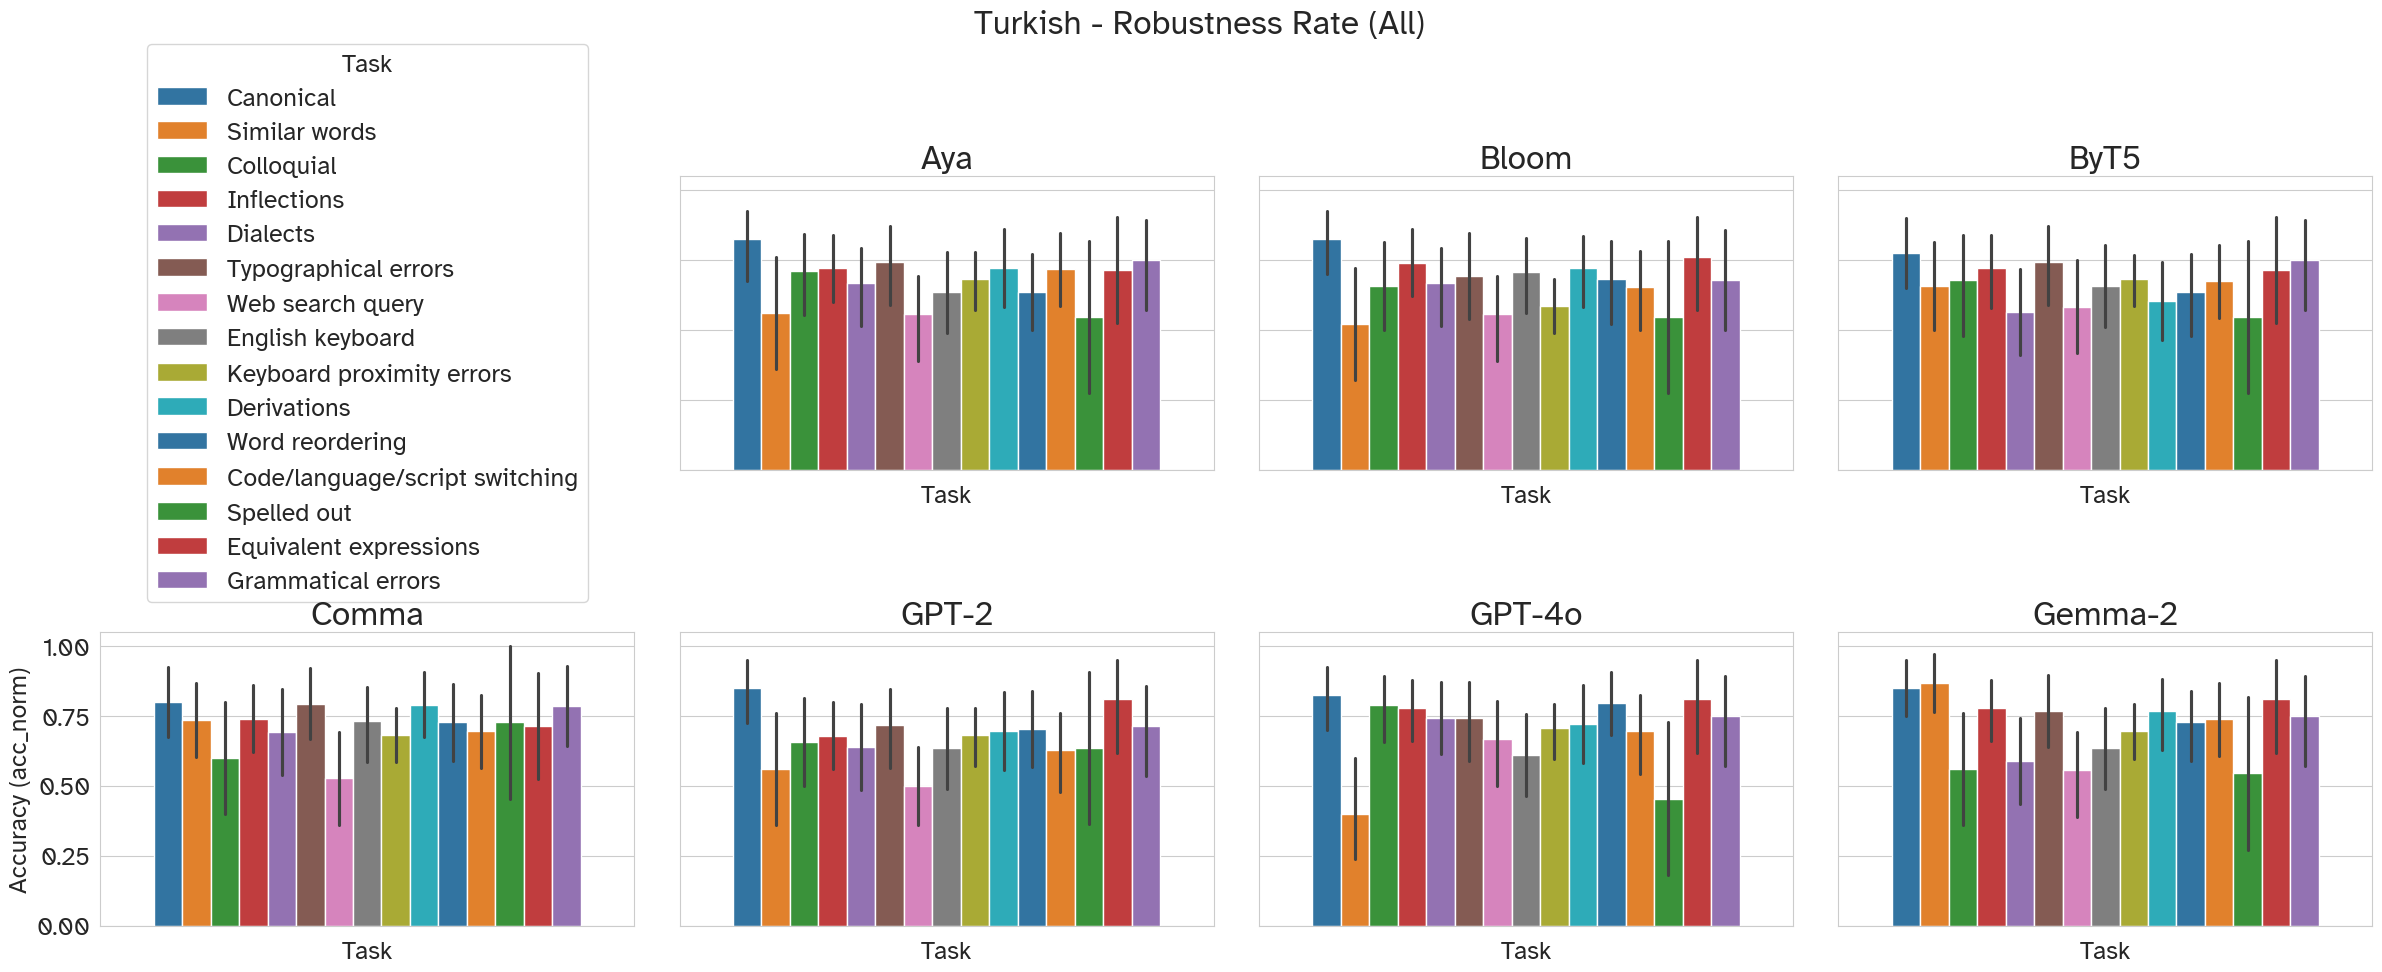

Plotting LLaMA into position 0
Plotting MBERT into position 1
Plotting Phi-3 into position 2
Plotting Qwen-3 into position 3
Plotting Tekken into position 4
Plotting TokenMonster into position 5
Plotting XGLM into position 6


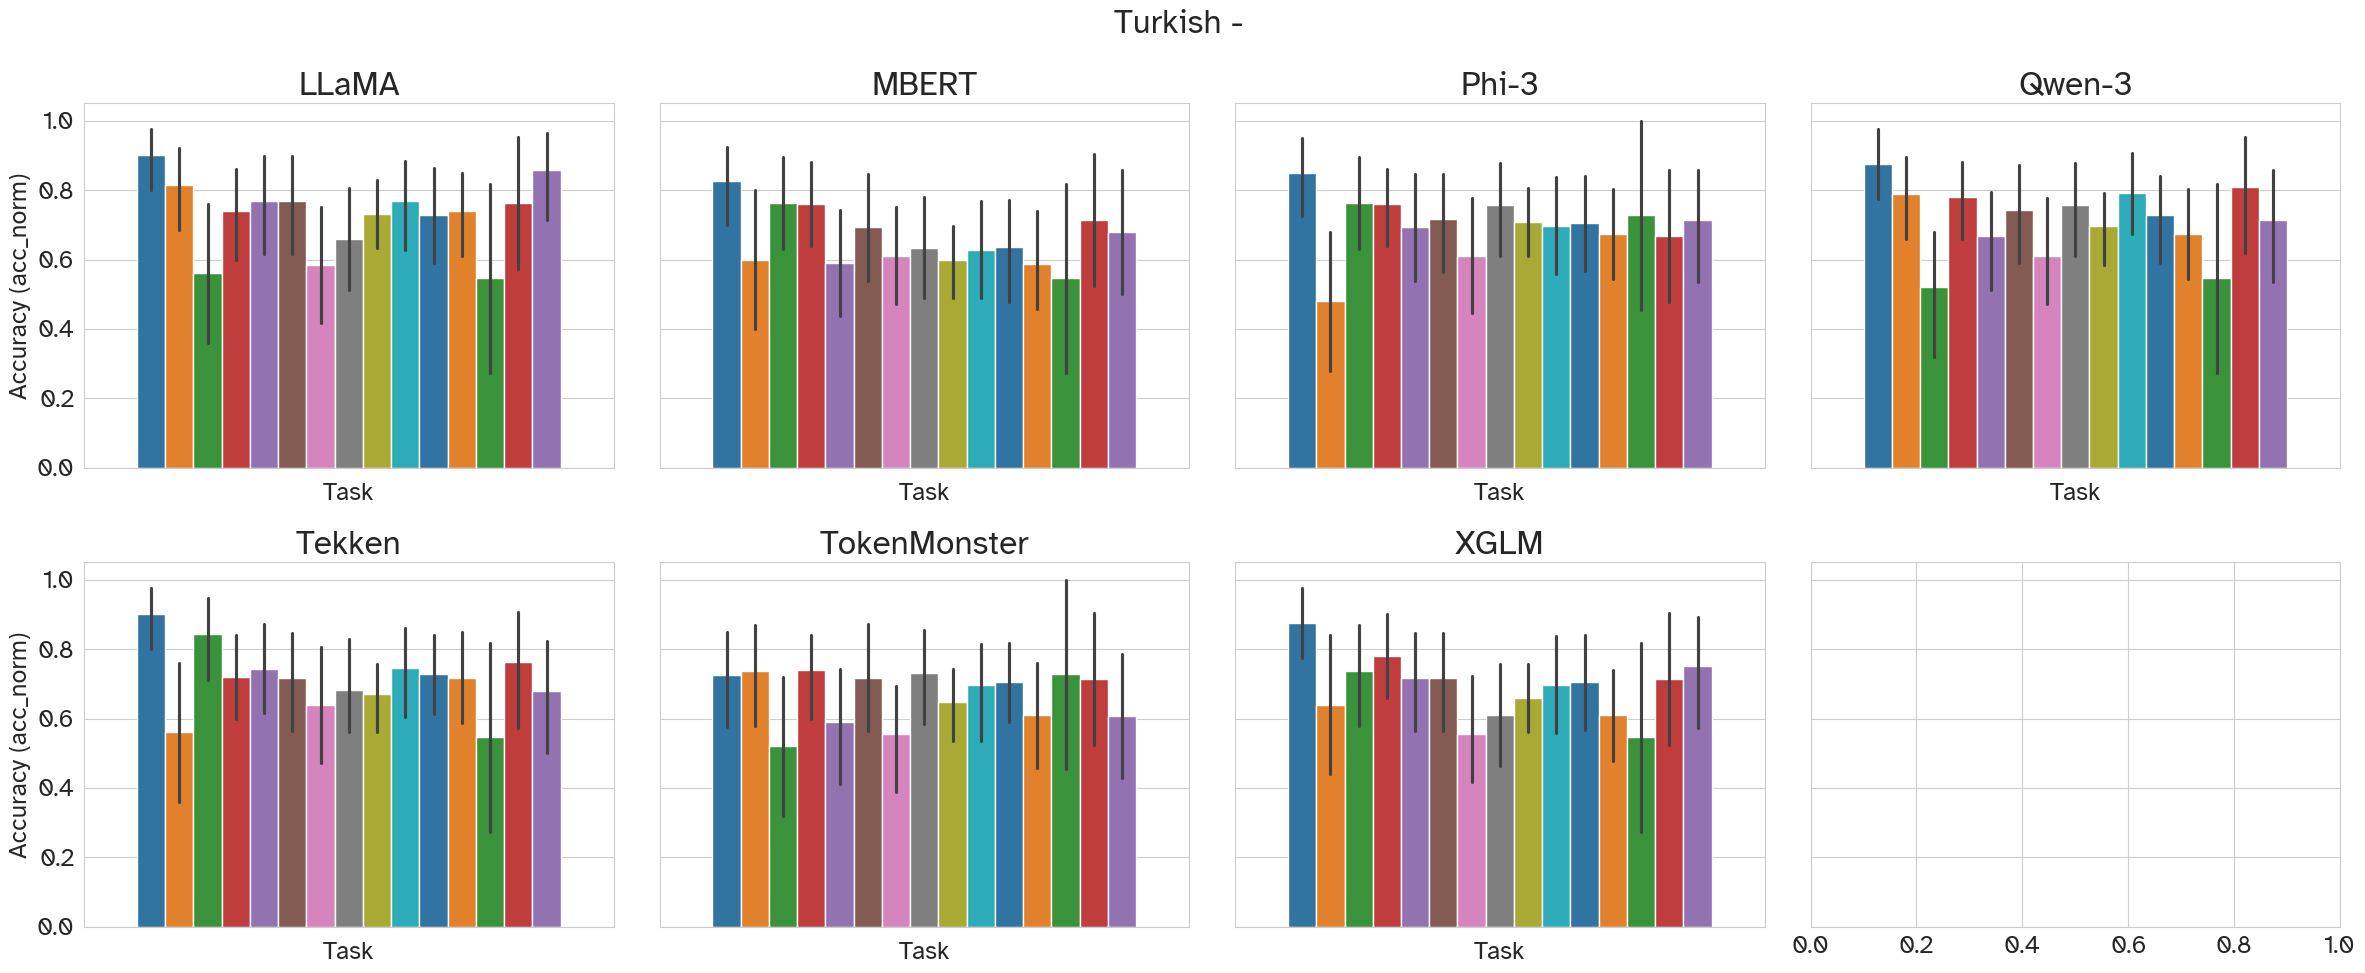

                                           acc_norm
model_name task_pretty_name                        
Aya        Canonical                       0.825000
           Code/language/script switching  0.717391
           Colloquial                      0.710526
           Derivations                     0.720930
           Dialects                        0.666667
...                                             ...
XGLM       Similar words                   0.640000
           Spelled out                     0.545455
           Typographical errors            0.717949
           Web search query                0.555556
           Word reordering                 0.704545

[210 rows x 1 columns]


In [ ]:
nrows, ncols = 2, 4
# PLOT_AXIS=
HUE="task_pretty_name"
# HUE="task"
fig, axs = get_new_fig(
    nrows=nrows, ncols=ncols, title=f"{title_pattern}Robustness Rate {suffix}"
)
fig_cnt = 0
models = samples["model_name"].unique()
for i, model in enumerate(models, 1):
    print(f"Plotting {model} into position {i % len(axs)}")
    filter_ = samples["model_name"] == model
    tmp = samples[filter_]
    ax = axs[i % len(axs)]
    sns.barplot(
        tmp, hue=HUE, y=METRIC, palette="tab10", ax=ax, legend=i == 1
    )
    ax.set_xlabel("Task")
    ax.set_ylabel(f"Accuracy ({METRIC})")
    title=model
    ax.set_title(title)
    # Check if we need to show the current figure
    is_last_task = i == len(models) + 1
    is_end_of_6 = (i + 1) % (nrows * ncols) == 0
    if i == 1:
        # Add legend to the first subplot of current figure
        handles, labels = axs[1].get_legend_handles_labels()
        axs[0].clear()
        axs[0].axis("off")
        axs[0].legend(handles, labels, title="Task", loc="center", ncol=1)
        axs[1].legend().set_visible(False)
    if is_last_task or is_end_of_6:
        # Hide any unused subplots in the current figure
        if is_last_task:
            num_plots_in_current_fig = (i % ncols * nrows) + 1
            for j in range(num_plots_in_current_fig, ncols * nrows):
                axs[j].set_visible(False)

        # Show the current figure
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")
        plt.show()
        fig_cnt += 1
        fig, axs = get_new_fig(nrows=nrows, ncols=ncols, title=title_pattern)
# Hide any unused subplots if there are fewer than 6 tasks
# for j in range((len(models)+1) % (ncols * nrows), ncols * nrows):
#     axs[j].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig(OUTPUT_DIR/f"by_model_{METRIC}_{fig_cnt}.pdf", pad_inches=0, bbox_inches="tight")

plt.show()

print(accuracies_by_model)

### Examples per perturbation

In [ ]:
all_samples[all_samples["model_name"] == "Aya"].pivot_table(index=["model_name", "task_pretty_name"], values=METRIC, aggfunc="count")


acc_norm
model_name task_pretty_name                        
Aya        Canonical                             40
           Code/language/script switching        46
           Colloquial                            38
           Derivations                           43
           Dialects                              39
           English keyboard                      41
           Equivalent expressions                21
           Grammatical errors                    28
           Inflections                           50
           Keyboard proximity errors             82
           Similar words                         25
           Spelled out                           11
           Typographical errors                  39
           Web search query                      36
           Word reordering                       44

### Against tokenizer props

#### Token count

In [ ]:
models = samples["model_name"].unique()

sns.histplot(samples, x="model_name", y="token_counts")

ValueError: Could not interpret value `token_counts` for `y`. An entry with this name does not appear in `data`.

In [ ]:
samples.columns

Index(['doc_id', 'target', 'resps', 'metrics', 'acc', 'acc_norm', 'model_name',
       'task', 'question', 'choices', 'answer', 'answer_label', 'split',
       'subcategories', 'categories', 'lang', 'second_lang', 'notes', 'id',
       'set_id', 'variation_id',
       'vanilla_cos_sim_to_canonical.CohereLabs/aya-expanse-8b',
       'vanilla_cos_sim_to_canonical.Qwen/Qwen3-8B',
       'vanilla_cos_sim_to_canonical.bigscience/bloom',
       'vanilla_cos_sim_to_canonical.common-pile/comma-v0.1-1t',
       'vanilla_cos_sim_to_canonical.facebook/xglm-564M',
       'vanilla_cos_sim_to_canonical.google-bert/bert-base-multilingual-cased',
       'vanilla_cos_sim_to_canonical.google/byt5-small',
       'vanilla_cos_sim_to_canonical.google/gemma-2-2b',
       'vanilla_cos_sim_to_canonical.gpt2',
       'vanilla_cos_sim_to_canonical.meta-llama/Llama-3.2-1B',
       'vanilla_cos_sim_to_canonical.microsoft/Phi-3-mini-4k-instruct',
       'vanilla_cos_sim_to_canonical.mistralai/tekken',
       'vani

In [ ]:
toks = samples["tokenizer_name"].unique()
tok_count_cols = [f"token_counts.{tok_name}" for tok_name in toks]
tok_counts = samples[tok_count_cols]
tok_counts.columns=toks
tok_counts 


,google/byt5-small,bigscience/bloom,common-pile/comma-v0.1-1t,google-bert/bert-base-multilingual-cased,Qwen/Qwen3-8B,gpt2,CohereLabs/aya-expanse-8b
0,80,35,41,25,23,42,22
1,26,11,12,9,10,15,6
2,20,8,9,7,8,12,5
3,49,22,26,19,25,22,23
4,40,14,23,13,22,20,20
...,...,...,...,...,...,...,...
4076,30,12,13,7,10,13,6
4077,29,10,10,7,9,12,5
4078,18,8,10,6,6,11,5
4079,27,10,13,9,10,14,7


In [ ]:
samples["tokenizer_name"]

0               google/byt5-small
1               google/byt5-small
2               google/byt5-small
3               google/byt5-small
4               google/byt5-small
                  ...            
4076    CohereLabs/aya-expanse-8b
4077    CohereLabs/aya-expanse-8b
4078    CohereLabs/aya-expanse-8b
4079    CohereLabs/aya-expanse-8b
4080    CohereLabs/aya-expanse-8b
Name: tokenizer_name, Length: 4081, dtype: object

In [ ]:
for i, row in samples.iterrows():
    samples.iloc[i, "token_count"]=

,doc_id,target,resps,metrics,acc,acc_norm,model_name,tokenizer_name,task,question,...,token_counts.google/gemma-2-2b,token_counts.gpt2,token_counts.meta-llama/Llama-3.2-1B,token_counts.microsoft/Phi-3-mini-4k-instruct,token_counts.mistralai/tekken,token_counts.tiktoken/gpt-4o,token_counts.tokenmonster/englishcode-32000-consistent-v1,answer_choice,task_pretty_name,is_canonical
0,0,0,"[[[-7.9375, False]], [[-15.0625, False]], [[-1...","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Dr Gülçiçek Bölükbaşı bir doktordur. Gülçiçek ...,...,23,42,28,37,26,26,54,doktorluktur,Derivations,False
1,1,2,"[[[-11.875, False]], [[-12.1875, False]], [[-1...","[acc, acc_norm]",1,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün renklenişi,...,7,15,8,12,9,8,17,mavidir,Derivations,False
2,2,3,"[[[-7.21875, False]], [[-11.0625, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Gökyüzünün rengi,...,5,12,8,9,8,6,14,mavimsidir,Derivations,False
3,3,0,"[[[-8.5625, False]], [[-16.25, False]], [[-18....","[acc, acc_norm]",1,1,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,"Bu ev 5,850,000 Lira fiyatlı. Bu evin maaliyeti",...,22,22,20,28,25,20,24,"5,850,000 TL'dir",Derivations,False
4,4,3,"[[[-13.8125, False]], [[-13.9375, False]], [[-...","[acc, acc_norm]",0,0,ByT5,google/byt5-small,tokenizer_robustness_completion_turkish_deriva...,Bugün 17/08/1998'dir. Bugünkü tarihi,...,20,20,16,24,21,16,25,17/8/1998'dir,Derivations,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4076,6,0,"[[[-16.75, False]], [[-12.625, False]], [[-12....","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir dakikadaki saniye sayısı,...,9,13,8,13,9,9,16,altmıştır,Spelled out,False
4077,7,2,"[[[-9.0625, False]], [[-8.125, False]], [[-8.5...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Bir altıgenin kenar sayısı,...,8,12,7,12,9,9,16,altıdır,Spelled out,False
4078,8,2,"[[[-11.6875, False]], [[-14.4375, False]], [[-...","[acc, acc_norm]",0,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Yüzün yüzde onu,...,5,11,5,10,6,5,11,ondur,Spelled out,False
4079,9,0,"[[[-11.875, False]], [[-15.375, False]], [[-16...","[acc, acc_norm]",1,0,Aya,CohereLabs/aya-expanse-8b,tokenizer_robustness_completion_turkish_spelle...,Seksenin yüzde yirmi beşi,...,9,14,10,14,11,9,16,yirmidir,Spelled out,False
